# EfficientNet-B4 Training (Standardized)

Standardized training pipeline matching DenseNet121 reference.

In [1]:
!pip install -q split-folders timm grad-cam

In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
import timm
import cv2
import numpy as np
import shutil
import glob
import splitfolders
import matplotlib.pyplot as plt
from PIL import Image
import copy
import time
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import random
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

device = torch.device("cpu")
print(f"Device: {device}")

Device: cpu


In [3]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os

# Check if running in Colab; if so, mount drive
if IN_COLAB and os.path.exists('/content/drive'):
    drive.mount('/content/drive')
else:
    print("Not running in Colab or Drive already mounted/dataset present locally.")

Not running in Colab or Drive already mounted/dataset present locally.


In [4]:
# Integrate existing Dataset folder (Local Path)
input_folder = "../Dataset"
output_folder = "dataset_split"

if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

print("Splitting dataset...")
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.7, .15, .15), group_prefix=None)
print("Dataset split complete.")

Splitting dataset...


Copying files: 1030 files [00:00, 4682.32 files/s]

Dataset split complete.


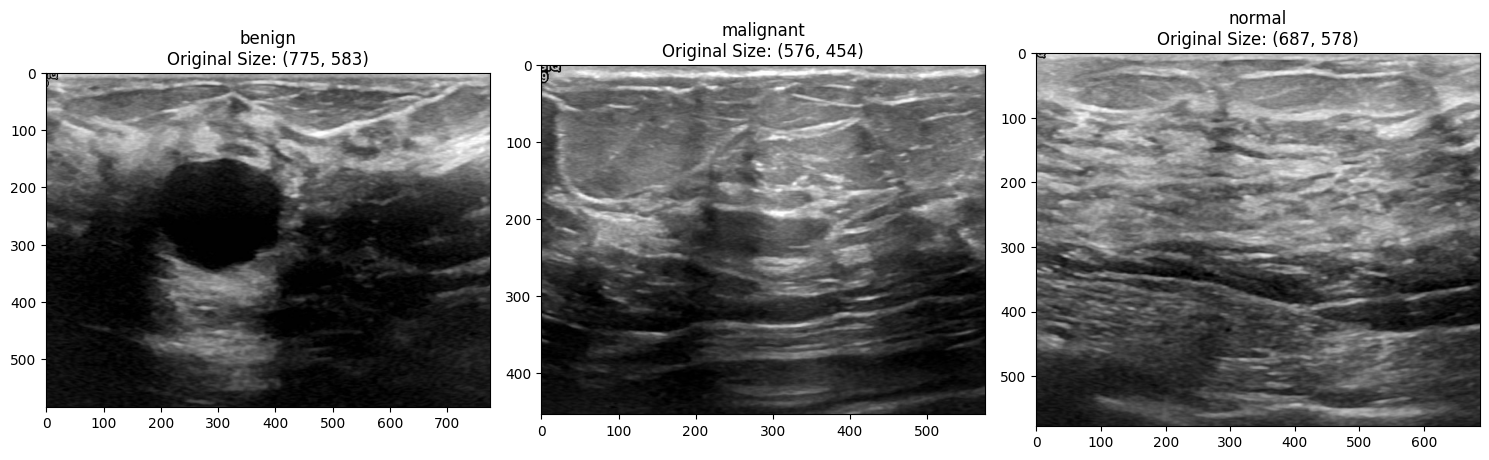

In [5]:
def show_raw_images(dataset_path, num_images=3):
    classes = ['benign', 'malignant', 'normal']
    plt.figure(figsize=(15, 5))
    for i, cls in enumerate(classes):
        class_folder = os.path.join(dataset_path, 'train', cls)
        if os.path.exists(class_folder) and len(os.listdir(class_folder)) > 0:
            random_img = random.choice(os.listdir(class_folder))
            img_path = os.path.join(class_folder, random_img)
            img = Image.open(img_path)
            plt.subplot(1, 3, i+1)
            plt.imshow(img, cmap='gray')
            plt.title(f"{cls}\nOriginal Size: {img.size}")
            plt.axis('on')
    plt.tight_layout()
    plt.show()

show_raw_images(output_folder)

In [6]:
class UltrasoundEnhancement(object):
    def __init__(self, apply_clahe=True, apply_denoise=True):
        self.apply_clahe = apply_clahe
        self.apply_denoise = apply_denoise

    def __call__(self, img):
        img_np = np.array(img.convert('L'))

        if self.apply_denoise:
            img_np = cv2.medianBlur(img_np, 5)

        if self.apply_clahe:
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            img_np = clahe.apply(img_np)

        img_rgb = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
        return Image.fromarray(img_rgb)

print("UltrasoundEnhancement class created.")

UltrasoundEnhancement class created.


In [7]:
data_transforms = {
    'train': transforms.Compose([
        UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
        transforms.Resize((224, 224)),
        transforms.RandomRotation(15),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        UltrasoundEnhancement(apply_clahe=True, apply_denoise=True),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

data_dir = "dataset_split"
print(f"Using dataset at: {data_dir}")
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'val', 'test']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x == 'train'), num_workers=2)
               for x in ['train', 'val', 'test']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Dataset Sizes: {dataset_sizes}")

Using dataset at: dataset_split
Classes: ['benign', 'malignant', 'normal']
Dataset Sizes: {'train': 719, 'val': 153, 'test': 158}


In [8]:
def get_model(model_name, num_classes):
    print(f"Creating model: {model_name}...")
    model = timm.create_model(model_name, pretrained=True)
    
    # Replace classifier head based on model structure
    if 'efficientnet' in model_name or 'mobilenet' in model_name:
        if hasattr(model, 'classifier'):
            in_features = model.classifier.in_features
            model.classifier = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(in_features, num_classes)
            )
        elif hasattr(model, 'fc'):
            in_features = model.fc.in_features
            model.fc = nn.Sequential(
                nn.Dropout(0.2),
                nn.Linear(in_features, num_classes)
            )
    
    return model.to(device)

# Instantiate EfficientNet-B4
model = get_model('efficientnet_b4', len(class_names))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 20

Creating model: efficientnet_b4...


In [9]:
def train_model(model, criterion, optimizer, num_epochs=20):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, history

In [10]:
model, history = train_model(model, criterion, optimizer, num_epochs=num_epochs)

# Save model
torch.save(model.state_dict(), 'efficientnet_b4_ultrasound.pth')
print("Model saved as efficientnet_b4_ultrasound.pth")

Epoch 1/20
----------
train Loss: 1.0510 Acc: 0.4882
val Loss: 1.0119 Acc: 0.5098

Epoch 2/20
----------
train Loss: 0.9519 Acc: 0.5271
val Loss: 0.9318 Acc: 0.5229

Epoch 3/20
----------
train Loss: 0.9019 Acc: 0.5647
val Loss: 0.8883 Acc: 0.6405

Epoch 4/20
----------
train Loss: 0.8636 Acc: 0.5855
val Loss: 0.8219 Acc: 0.6536

Epoch 5/20
----------
train Loss: 0.8048 Acc: 0.6134
val Loss: 0.7777 Acc: 0.6732

Epoch 6/20
----------
train Loss: 0.7465 Acc: 0.6606
val Loss: 0.7085 Acc: 0.7059

Epoch 7/20
----------
train Loss: 0.6607 Acc: 0.7163
val Loss: 0.6548 Acc: 0.7320

Epoch 8/20
----------
train Loss: 0.5778 Acc: 0.7455
val Loss: 0.6004 Acc: 0.7647

Epoch 9/20
----------
train Loss: 0.5336 Acc: 0.7733
val Loss: 0.5771 Acc: 0.7843

Epoch 10/20
----------
train Loss: 0.4675 Acc: 0.8220
val Loss: 0.5431 Acc: 0.7843

Epoch 11/20
----------
train Loss: 0.4099 Acc: 0.8359
val Loss: 0.5452 Acc: 0.7778

Epoch 12/20
----------
train Loss: 0.4058 Acc: 0.8331
val Loss: 0.5210 Acc: 0.7908

E

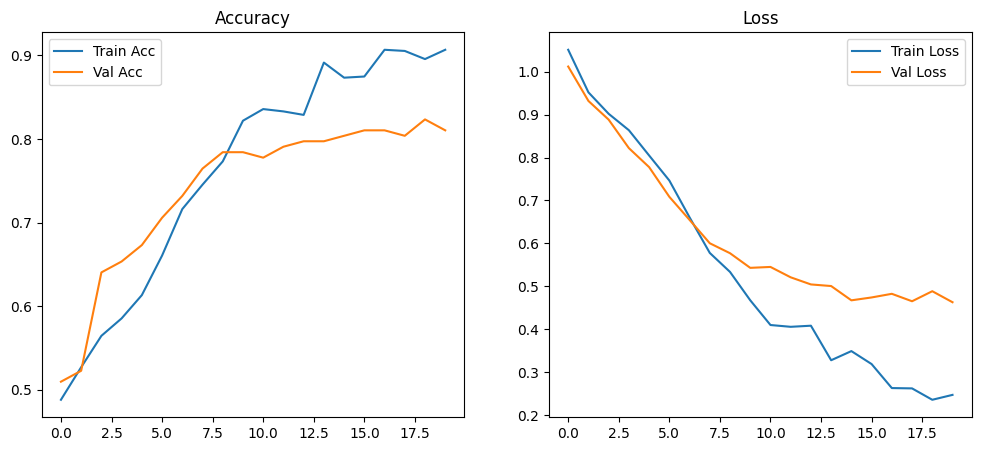

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

Evaluating on Test Set...
Classification Report:
              precision    recall  f1-score   support

      benign     0.8539    0.9268    0.8889        82
   malignant     0.9362    0.8000    0.8627        55
      normal     0.8636    0.9048    0.8837        21

    accuracy                         0.8797       158
   macro avg     0.8846    0.8772    0.8785       158
weighted avg     0.8838    0.8797    0.8791       158



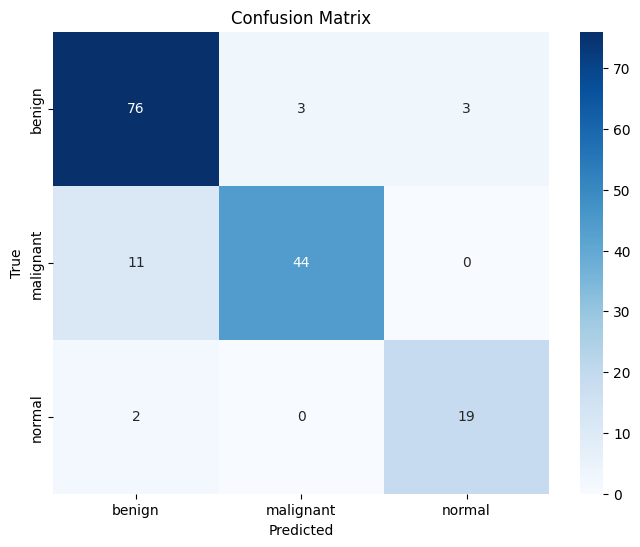

In [12]:
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

print("Evaluating on Test Set...")
evaluate_model(model, dataloaders['test'])

Showing GradCAM results on Test Set...


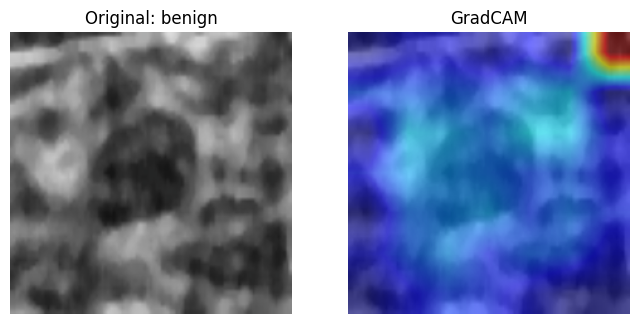

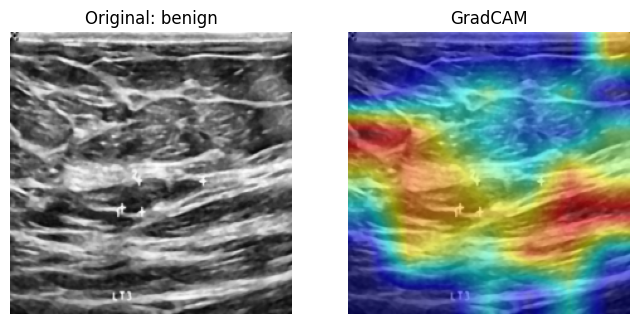

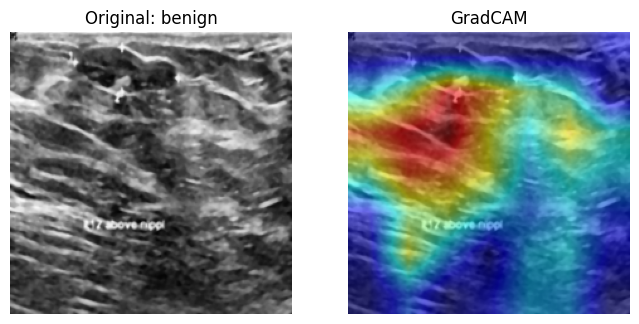

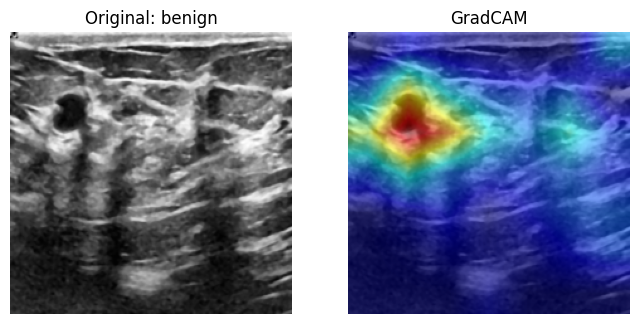

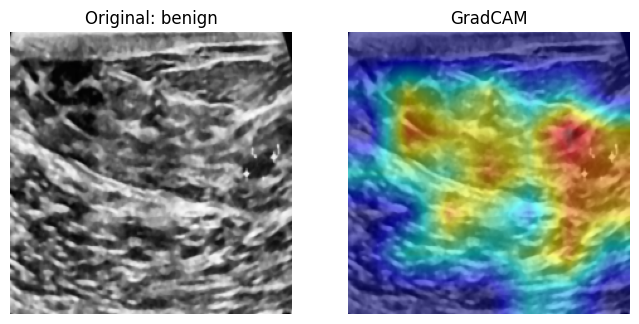

In [13]:
# GradCAM Visualization
model.eval()

# EfficientNet target layer: usually conv_head or similar. Timm efficientnet uses 'conv_head'.
target_layers = [model.conv_head]

cam = GradCAM(model=model, target_layers=target_layers)

def show_gradcam(dataset, num_images=5):
    indices = random.sample(range(len(dataset)), num_images)

    for i in indices:
        img_tensor, label = dataset[i]
        img_tensor = img_tensor.unsqueeze(0).to(device)

        # Generate CAM
        targets = [ClassifierOutputTarget(label)]
        grayscale_cam = cam(input_tensor=img_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :]

        # Prepare original image for visualization
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = img_tensor.cpu().squeeze().permute(1, 2, 0).numpy()
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)

        visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(img_np)
        plt.title(f"Original: {class_names[label]}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(visualization)
        plt.title("GradCAM")
        plt.axis('off')
        plt.show()

print("Showing GradCAM results on Test Set...")
show_gradcam(image_datasets['test'])

Found 3 manual images to process.
Processing manual image: ../Dataset/benign/benign (2).png


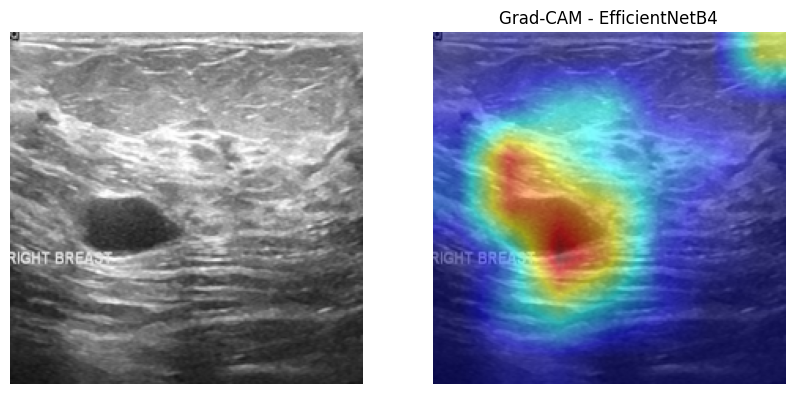

Processing manual image: ../Dataset/malignant/malignant (4).png


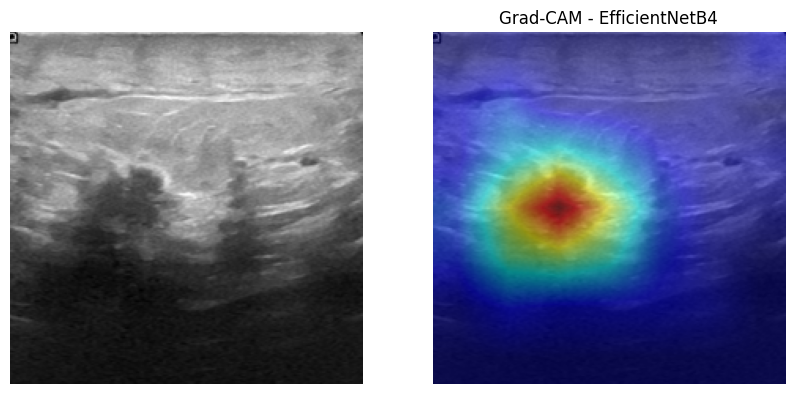

Processing manual image: ../Dataset/normal/normal (4).png


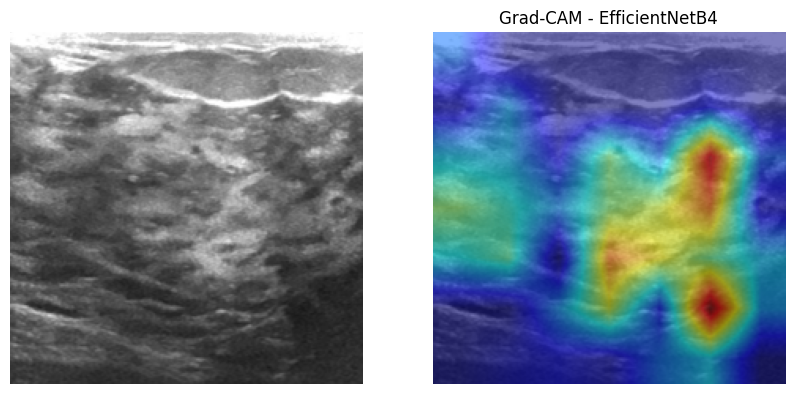

In [14]:
# Grad-CAM Visualization with Manual Path Support
import PIL.Image
import cv2
import numpy as np
import torch
from torchvision import transforms

# --- USER CONFIGURATION ---
# Enter paths to your test images here.
test_image_paths = [
    '../Dataset/benign/benign (2).png',
    '../Dataset/malignant/malignant (4).png',
    '../Dataset/normal/normal (4).png'
]
# --------------------------

def get_target_layers(model):
    if hasattr(model, 'features'): return [model.features[-1]]
    if hasattr(model, 'blocks'): return [model.blocks[-1]]
    if hasattr(model, 'conv_head'): return [model.conv_head]
    # Fallback search
    last_conv = None
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            last_conv = module
    if last_conv: return [last_conv]
    raise AttributeError("Could not find a suitable target layer for Grad-CAM")

def predict_single_image_gradcam(model, image_path, class_names):
    print(f"Processing manual image: {image_path}")
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    try:
        if not os.path.exists(image_path):
            print(f"Error: Image not found at {image_path}")
            return
            
        image = PIL.Image.open(image_path).convert('RGB')
        input_tensor = transform(image).unsqueeze(0).to(device)
        
        model.eval()
        target_layers = get_target_layers(model)
        cam = GradCAM(model=model, target_layers=target_layers)
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
        
        # Prediction
        with torch.no_grad():
            outputs = model(input_tensor)
            prob = torch.nn.functional.softmax(outputs, dim=1)
            score, preds = torch.max(prob, 1)
            predicted_label = class_names[preds[0]]
            confidence = score.item()
            
        # Visualization
        img_display = np.array(image.resize((224, 224))) / 255.0
        visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)
        
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].imshow(img_display)
        ax[0].axis('off')
        
        ax[1].imshow(visualization)
        ax[1].set_title("Grad-CAM - EfficientNetB4")
        ax[1].axis('off')
        plt.show()
        
    except Exception as e:
        print(f"Error processing manual image: {e}")
        import traceback
        traceback.print_exc()

def visualize_gradcam_fixed(model, test_dataset, class_names):
    model.eval()
    try:
       target_layers = get_target_layers(model)
    except AttributeError as e:
       print(e); return

    class_indices = {}
    for idx in range(len(test_dataset)):
        _, label = test_dataset[idx]
        class_name = class_names[label]
        if class_name not in class_indices:
            class_indices[class_name] = idx
        if len(class_indices) == len(class_names):
            break
            
    count = len(class_indices)
    fig = plt.figure(figsize=(15, 5 * count))
    
    for i, (class_name, idx) in enumerate(class_indices.items()):
        image, label = test_dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)
        cam = GradCAM(model=model, target_layers=target_layers)
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
        img_display = image.permute(1, 2, 0).cpu().numpy()
        img_display = (img_display * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
        img_display = np.clip(img_display, 0, 1)
        visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

        ax = fig.add_subplot(count, 2, 2*i + 1)
        ax.imshow(img_display)
        ax.set_title(f"Original: {class_name}")
        ax.axis('off')
        ax = fig.add_subplot(count, 2, 2*i + 2)
        ax.imshow(visualization)
        ax.set_title(f"Grad-CAM: {class_name}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# --- Execution Logic ---
manual_images_processed = False
if 'test_image_paths' in locals() and test_image_paths:
    print(f"Found {len(test_image_paths)} manual images to process.")
    for img_path in test_image_paths:
        if img_path: # Skip empty strings
            predict_single_image_gradcam(model, img_path, class_names)
            manual_images_processed = True

if not manual_images_processed:
    print("No manual images found/processed. Generating Grad-CAM for fixed examples from dataset...")
    if 'image_datasets' in locals() and 'test' in image_datasets:
        visualize_gradcam_fixed(model, image_datasets['test'], class_names)
    elif 'dataset_test' in locals():
        visualize_gradcam_fixed(model, dataset_test, class_names)
    else:
        print("Error: Test dataset not found.")